In [39]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [40]:
X = pd.read_csv("../X.csv").values
y = pd.read_csv("../y.csv").values.ravel()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train = X_train[:, :-1]
X_test_sem_src = X_test[:, :-1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test_sem_src)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, random_state=42)
}

predicoes = {}

for nome, modelo in modelos.items():
    print(f"Treinando o modelo: {nome}")
    
    modelo.fit(X_train_scaled, y_train)
    
    predicoes[nome] = modelo.predict(X_test_scaled)
    print(f"{nome} finalizado")

Treinando o modelo: Random Forest
Random Forest finalizado
Treinando o modelo: SVM
SVM finalizado


Classificação de Random Forest
              precision    recall  f1-score   support

       fresh       0.98      0.99      0.98       294
      rotten       0.99      0.98      0.99       319

    accuracy                           0.99       613
   macro avg       0.99      0.99      0.99       613
weighted avg       0.99      0.99      0.99       613

--------------------------------------------------
Classificação de SVM
              precision    recall  f1-score   support

       fresh       0.90      1.00      0.95       294
      rotten       1.00      0.90      0.95       319

    accuracy                           0.95       613
   macro avg       0.95      0.95      0.95       613
weighted avg       0.95      0.95      0.95       613

--------------------------------------------------


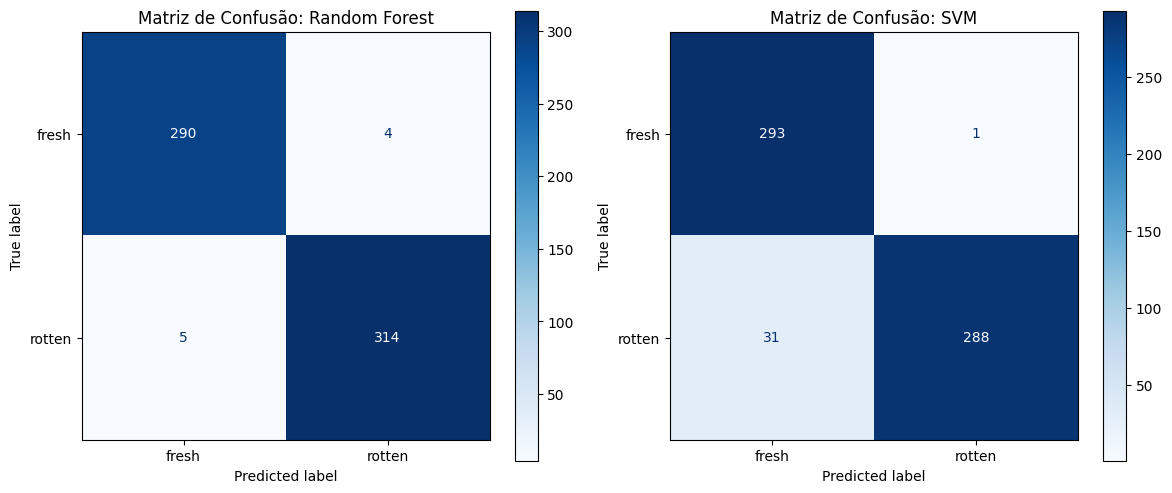

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (nome, preds) in enumerate(predicoes.items()):
    print(f"Classificação de {nome}")
    print(classification_report(y_test, preds))
    print("-" * 50)
    
    cm = confusion_matrix(y_test, preds, labels=["fresh", "rotten"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fresh", "rotten"])
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, values_format='d')
    axes[idx].set_title(f"Matriz de Confusão: {nome}")

plt.tight_layout()
plt.savefig("../outputs/matrizes-de-confusao/matrizes.jpg")
plt.show()

In [47]:
for k, p in predicoes.items():
    erros = []
    for i in range(0, len(p)):
        if p[i] != y_test[i]:
            erros.append(X_test[i][-1])
    
    caminho = k.replace(" ", "-")
    for e in erros:
        plt.imread(e)
        plt.show()
        plt.savefig(f"../outputs/imagens-de-erros/{caminho}/{os.path.basename(e)}")


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>